<a href="https://colab.research.google.com/github/sonicmortis/2311532020-Luthfi-Kautsar-Rizata-ImageProcessing/blob/main/2311532020_Image_Enhancement_untuk_Normalisasi_Histogram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [5]:
img = Image.open("Dazai Osamu.jpg").convert("L")
img_array = np.array(img)

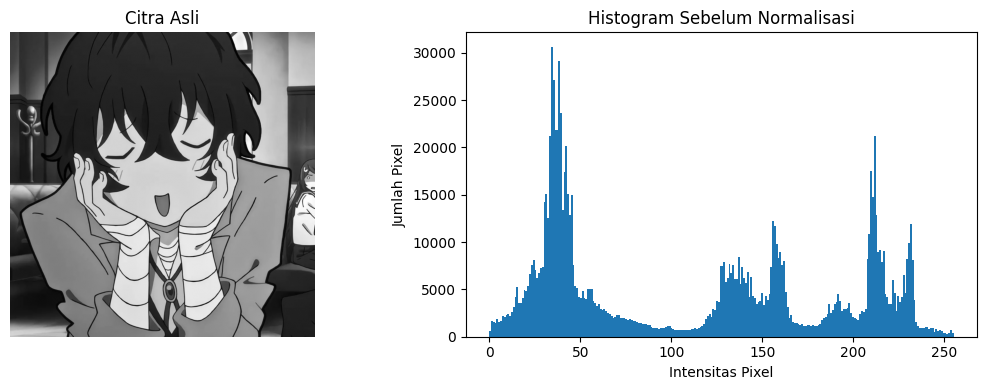

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11,4))

# Subplot 1 — Image
ax[0].imshow(img_array, cmap='gray')
ax[0].set_title("Citra Asli")
ax[0].axis('off')

# Subplot 2 — Histogram
ax[1].hist(img_array.flatten(), bins=256)
ax[1].set_title("Histogram Sebelum Normalisasi")
ax[1].set_xlabel("Intensitas Pixel")
ax[1].set_ylabel("Jumlah Pixel")

plt.tight_layout()
plt.show()

In [10]:
I_min = img_array.min()
I_max = img_array.max()

norm_img = (img_array - I_min) / (I_max - I_min) * 255
norm_img = norm_img.astype(np.uint8)

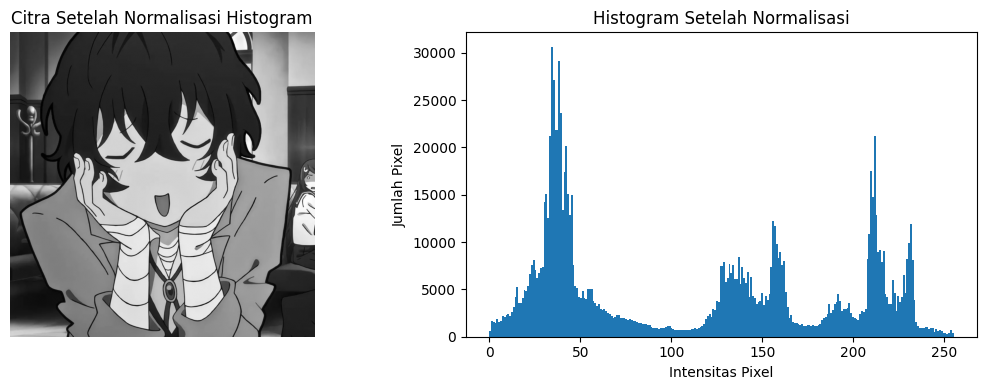

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11,4))

# Subplot 1 — Normalized Image
ax[0].imshow(norm_img, cmap='gray')
ax[0].set_title("Citra Setelah Normalisasi Histogram")
ax[0].axis('off')

# Subplot 2 — Histogram Normalized
ax[1].hist(norm_img.flatten(), bins=256)
ax[1].set_title("Histogram Setelah Normalisasi")
ax[1].set_xlabel("Intensitas Pixel")
ax[1].set_ylabel("Jumlah Pixel")

plt.tight_layout()
plt.show()

In [11]:
hist, bins = np.histogram(norm_img.flatten(), 256, [0,256])

cdf = hist.cumsum()

cdf_normalized = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())
cdf_normalized = cdf_normalized.astype(np.uint8)

equalized_img = cdf_normalized[norm_img]

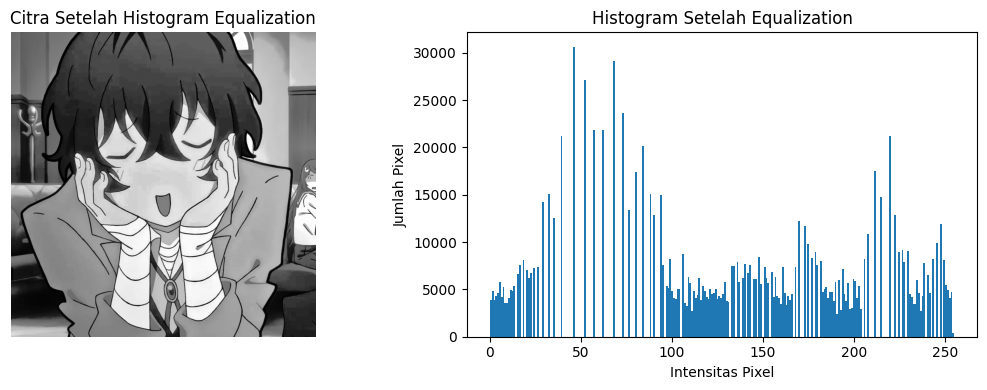

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(11,4))

# Subplot 1 — Equalized Image
ax[0].imshow(equalized_img, cmap='gray')
ax[0].set_title("Citra Setelah Histogram Equalization")
ax[0].axis('off')

# Subplot 2 — Histogram Equalized
ax[1].hist(equalized_img.flatten(), bins=256)
ax[1].set_title("Histogram Setelah Equalization")
ax[1].set_xlabel("Intensitas Pixel")
ax[1].set_ylabel("Jumlah Pixel")

plt.tight_layout()
plt.show()